In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Running ISTA...
Running FISTA...
Computing approximate optimal minimum...


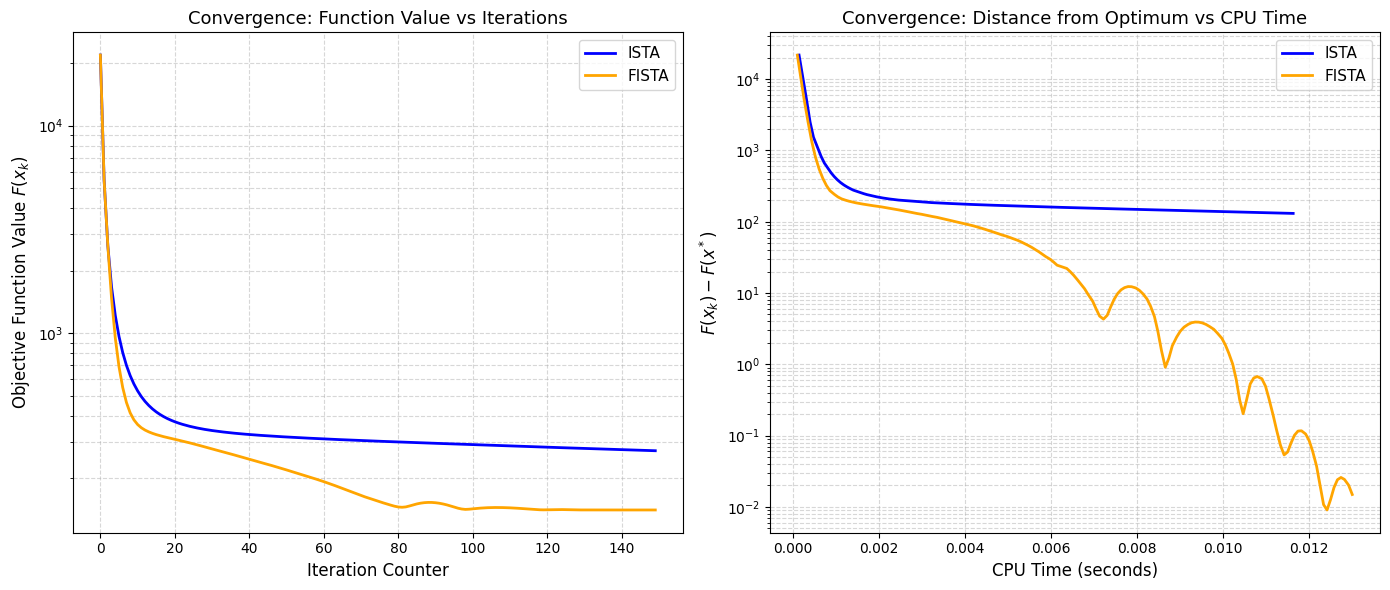


--- Summary ---
Initial Objective Value: 21877.1321
Final ISTA Objective Value: 271.4532
Final FISTA Objective Value: 140.6846


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ---------------------------------------------------------
# 1. SOFT THRESHOLDING (PROXIMAL OPERATOR FOR L1-NORM)
# ---------------------------------------------------------
def soft_thresholding(x, lmbda):
    """
    Proximal operator of the l1-norm.
    S_lambda(x) = sign(x) * max(|x| - lambda, 0)
    """
    return np.sign(x) * np.maximum(np.abs(x) - lmbda, 0)

# ---------------------------------------------------------
# 2. OBJECTIVE FUNCTION CALCULATION
# ---------------------------------------------------------
def compute_objective(A, b, x, lmbda):
    """
    F(x) = 0.5 * ||Ax - b||_2^2 + lmbda * ||x||_1
    """
    residual = A @ x - b
    f_x = 0.5 * np.sum(residual ** 2)
    g_x = lmbda * np.sum(np.abs(x))
    return f_x + g_x

# ---------------------------------------------------------
# 3. ISTA IMPLEMENTATION
# ---------------------------------------------------------
def ista(A, b, lmbda, max_iter=200, tol=1e-8):
    """
    Iterative Shrinkage-Thresholding Algorithm (ISTA)
    """
    n_features = A.shape[1]
    x = np.zeros(n_features)
    
    # Compute Lipschitz constant (L) = max eigenvalue of (A^T * A)
    L = np.max(np.linalg.eigvals(A.T @ A).real)
    step_size = 1.0 / L
    
    objectives = []
    times = []
    
    start_time = time.time()
    for i in range(max_iter):
        # Current objective value
        obj = compute_objective(A, b, x, lmbda)
        objectives.append(obj)
        times.append(time.time() - start_time)
        
        # Gradient step
        grad = A.T @ (A @ x - b)
        x_new = x - step_size * grad
        
        # Proximal step
        x_new = soft_thresholding(x_new, lmbda * step_size)
        
        # Convergence check
        if np.linalg.norm(x_new - x) / (np.linalg.norm(x) + 1e-8) < tol:
            break
            
        x = x_new
        
    return x, objectives, times

# ---------------------------------------------------------
# 4. FISTA IMPLEMENTATION
# ---------------------------------------------------------
def fista(A, b, lmbda, max_iter=200, tol=1e-8):
    """
    Fast Iterative Shrinkage-Thresholding Algorithm (FISTA)
    """
    n_features = A.shape[1]
    x = np.zeros(n_features)
    y = np.zeros(n_features)  # Accelerated point
    t = 1.0
    
    # Compute Lipschitz constant
    L = np.max(np.linalg.eigvals(A.T @ A).real)
    step_size = 1.0 / L
    
    objectives = []
    times = []
    
    start_time = time.time()
    for i in range(max_iter):
        # Current objective value
        obj = compute_objective(A, b, x, lmbda)
        objectives.append(obj)
        times.append(time.time() - start_time)
        
        x_old = x.copy()
        
        # Gradient step on accelerated point y
        grad_y = A.T @ (A @ y - b)
        y_step = y - step_size * grad_y
        
        # Proximal step
        x = soft_thresholding(y_step, lmbda * step_size)
        
        # Convergence check
        if np.linalg.norm(x - x_old) / (np.linalg.norm(x_old) + 1e-8) < tol:
            break
            
        # Momentum updates
        t_next = (1.0 + np.sqrt(1.0 + 4.0 * t**2)) / 2.0
        y = x + ((t - 1.0) / t_next) * (x - x_old)
        t = t_next
        
    return x, objectives, times

# ---------------------------------------------------------
# 5. DATA GENERATION & EXECUTION
# ---------------------------------------------------------
if __name__ == "__main__":
    # Seed set karein taaki har baar same data bane
    np.random.seed(42)
    
    # Underdetermined system create karein (m < n)
    m, n = 150, 300  
    A = np.random.randn(m, n)
    
    # True sparse signal setup (sirf 15 elements non-zero hain)
    x_true = np.zeros(n)
    active_indices = np.random.choice(n, 15, replace=False)
    x_true[active_indices] = np.random.randn(15) * 5
    
    # Noisy measurements b = Ax + noise
    noise = np.random.randn(m) * 0.1
    b = A @ x_true + noise
    
    # Regularization parameter lambda
    lmbda = 2.5
    iterations = 150
    
    # Algorithms run karein
    print("Running ISTA...")
    x_ista, ista_objs, ista_times = ista(A, b, lmbda, max_iter=iterations)
    
    print("Running FISTA...")
    x_fista, fista_objs, fista_times = fista(A, b, lmbda, max_iter=iterations)
    
    # Approx Optimal Value (Bahut zyada iterations chala kar theoretical minimum approximation)
    print("Computing approximate optimal minimum...")
    _, final_objs, _ = fista(A, b, lmbda, max_iter=1000)
    f_star = final_objs[-1] - 1e-6 # Thoda sa minus taaki log scale par value 0 na ho jaye
    
    # ---------------------------------------------------------
    # 6. PLOTTING THE PAPERS' RESULTS (MULTIPLE GRAPHS)
    # ---------------------------------------------------------
    plt.figure(figsize=(14, 6))
    
    # --- GRAPH 1: Objective Function Value vs Iterations (Log Scale) ---
    plt.subplot(1, 2, 1)
    plt.plot(ista_objs, label='ISTA', color='blue', linewidth=2)
    plt.plot(fista_objs, label='FISTA', color='orange', linewidth=2)
    plt.yscale('log') # LOGARITHMIC SCALE
    plt.xlabel('Iteration Counter', fontsize=12)
    plt.ylabel('Objective Function Value $F(x_k)$', fontsize=12)
    plt.title('Convergence: Function Value vs Iterations', fontsize=13)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11)
    
    # --- GRAPH 2: F(x_k) - F(x*) vs CPU Time (Seconds) ---
    plt.subplot(1, 2, 2)
    # Distance from optimum find karein
    ista_diff = [max(obj - f_star, 1e-10) for obj in ista_objs]
    fista_diff = [max(obj - f_star, 1e-10) for obj in fista_objs]
    
    plt.plot(ista_times, ista_diff, label='ISTA', color='blue', linewidth=2)
    plt.plot(fista_times, fista_diff, label='FISTA', color='orange', linewidth=2)
    plt.yscale('log') # LOGARITHMIC SCALE
    plt.xlabel('CPU Time (seconds)', fontsize=12)
    plt.ylabel('$F(x_k) - F(x^*)$', fontsize=12)
    plt.title('Convergence: Distance from Optimum vs CPU Time', fontsize=13)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # --- Performance Output ---
    print("\n--- Summary ---")
    print(f"Initial Objective Value: {compute_objective(A, b, np.zeros(n), lmbda):.4f}")
    print(f"Final ISTA Objective Value: {ista_objs[-1]:.4f}")
    print(f"Final FISTA Objective Value: {fista_objs[-1]:.4f}")